In [9]:
# notebook cell: load the cleaned data into the EDA notebook fresh
import sys
sys.path.append("..")
import pandas as pd

mbeya_clean = pd.read_csv("../data/processed/mbeya_clean.csv", parse_dates=["date"])
iringa_clean = pd.read_csv("../data/processed/iringa_clean.csv", parse_dates=["date"])

mbeya_series = mbeya_clean.set_index("date")["price"]
iringa_series = iringa_clean.set_index("date")["price"]

print(mbeya_series.shape, iringa_series.shape)

(241,) (243,)


In [10]:
# ADF stationarity test -- per proposal Section 3.6.4
# tests raw series first; if non-stationary (p > 0.05), tests first difference too
from statsmodels.tsa.stattools import adfuller

def run_adf(series, name):
    result = adfuller(series.dropna())
    print(f"=== {name} (raw) ===")
    print(f"ADF stat: {result[0]:.4f}  p-value: {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"  {k} critical value: {v:.4f}")
    if result[1] <= 0.05:
        print("stationary (reject H0)\n")
    else:
        print("non-stationary (fail to reject H0) -- testing first difference\n")
        diff = series.diff().dropna()
        result2 = adfuller(diff)
        print(f"=== {name} (first difference) ===")
        print(f"ADF stat: {result2[0]:.4f}  p-value: {result2[1]:.4f}")
        for k, v in result2[4].items():
            print(f"  {k} critical value: {v:.4f}")
        if result2[1] <= 0.05:
            print("stationary after 1st differencing (reject H0)\n")
        else:
            print("still non-stationary -- needs further differencing\n")

run_adf(mbeya_series, "Mbeya")
run_adf(iringa_series, "Iringa")

=== Mbeya (raw) ===
ADF stat: -2.3613  p-value: 0.1530
  1% critical value: -3.4596
  5% critical value: -2.8744
  10% critical value: -2.5736
non-stationary (fail to reject H0) -- testing first difference

=== Mbeya (first difference) ===
ADF stat: -4.7961  p-value: 0.0001
  1% critical value: -3.4596
  5% critical value: -2.8744
  10% critical value: -2.5736
stationary after 1st differencing (reject H0)

=== Iringa (raw) ===
ADF stat: -3.0762  p-value: 0.0284
  1% critical value: -3.4579
  5% critical value: -2.8737
  10% critical value: -2.5732
stationary (reject H0)



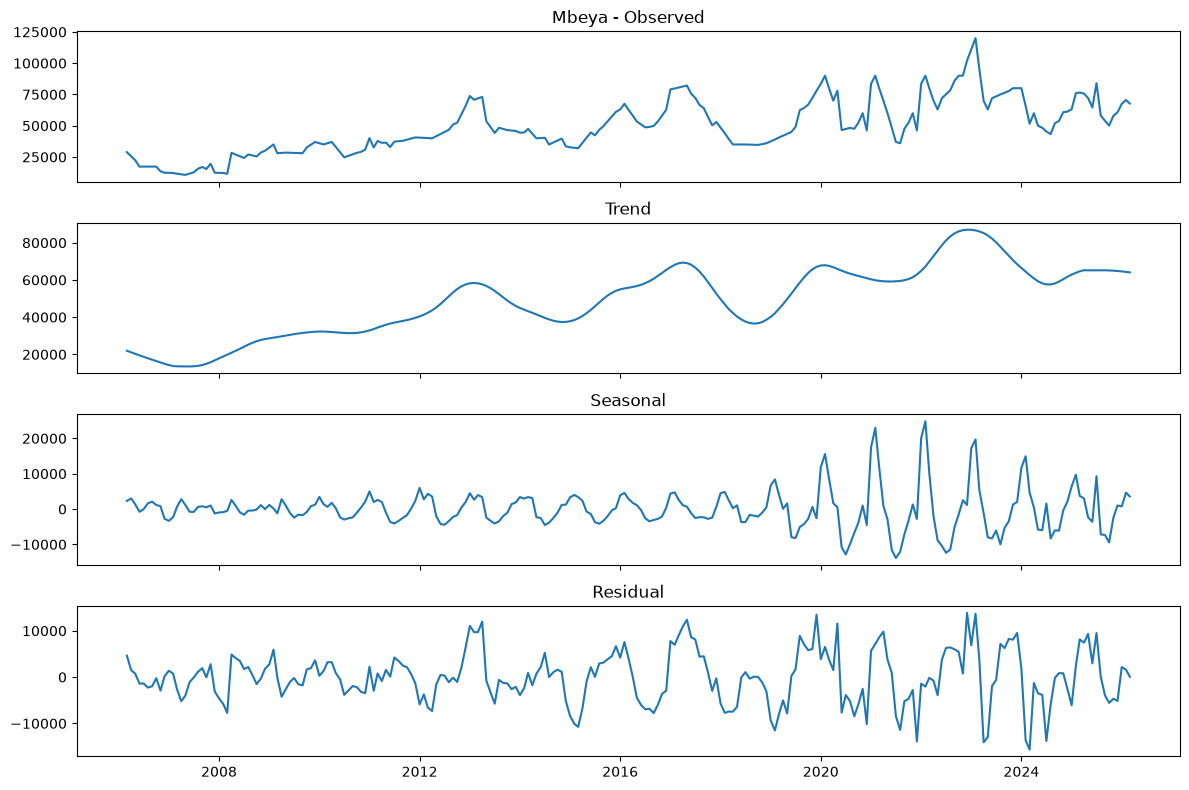

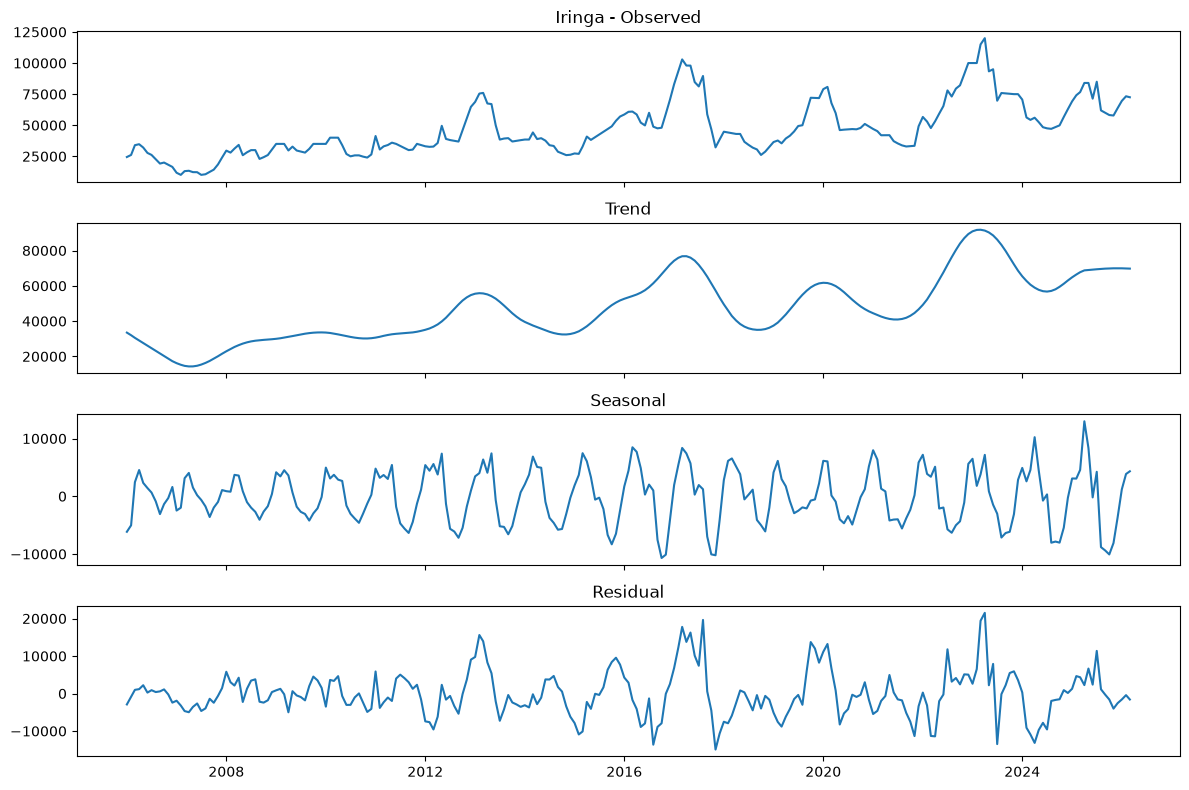

In [11]:
# STL decomposition -- per proposal Section 3.6.5
# splits each series into trend, seasonal, and residual components
# period=12 because data is monthly with expected annual seasonality
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

def run_stl(series, name):
    stl = STL(series, period=12)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(series.index, series.values)
    axes[0].set_title(f"{name} - Observed")
    axes[1].plot(series.index, result.trend)
    axes[1].set_title("Trend")
    axes[2].plot(series.index, result.seasonal)
    axes[2].set_title("Seasonal")
    axes[3].plot(series.index, result.resid)
    axes[3].set_title("Residual")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/{name.lower()}_stl.png", dpi=150)
    plt.show()

    return result

mbeya_stl = run_stl(mbeya_series, "Mbeya")
iringa_stl = run_stl(iringa_series, "Iringa")

In [8]:
# inspect the suspicious low-value period directly in both raw series
mask = (mbeya_series.index >= "2017-01-01") & (mbeya_series.index <= "2019-06-01")
print("=== Mbeya 2017-2019 ===")
print(mbeya_series[mask])

mask2 = (iringa_series.index >= "2017-01-01") & (iringa_series.index <= "2019-06-01")
print("\n=== Iringa 2017-2019 ===")
print(iringa_series[mask2])

=== Mbeya 2017-2019 ===
date
2017-01-01    79031.250
2017-02-01    79801.215
2017-03-01    80571.180
2017-04-01    81341.145
2017-05-01    82111.110
2017-06-01    75583.330
2017-07-01    72214.290
2017-08-01    66611.000
2017-09-01    64000.000
2017-10-01      442.200
2017-11-01    50333.330
2017-12-01    53000.000
2018-01-01    48500.000
2018-02-01    44000.000
2018-03-01    39500.000
2018-04-01    35000.000
2018-05-01    35000.000
2018-06-01    35000.000
2018-07-01    35000.000
2018-08-01    17647.520
2018-09-01      295.040
2018-10-01    34666.670
2018-11-01    35272.730
2018-12-01    36000.000
2019-01-01    37500.000
2019-02-01    39000.000
2019-03-01    40500.000
2019-04-01    42000.000
2019-05-01    43500.000
2019-06-01    45000.000
Name: price, dtype: float64

=== Iringa 2017-2019 ===
date
2017-01-01     83000.000
2017-02-01     93611.110
2017-03-01    102916.670
2017-04-01     98000.000
2017-05-01     97944.440
2017-06-01     84700.000
2017-07-01     81200.000
2017-08-01     89

In [12]:
# sanity check: confirm Iringa differenced series isn't ALSO stationary 
# (it should be, differencing a stationary series just adds noise -- 
# but let's see how much margin we actually have)
iringa_diff = iringa_series.diff().dropna()
result = adfuller(iringa_diff)
print(f"Iringa (first difference) -- sanity check")
print(f"ADF stat: {result[0]:.4f}  p-value: {result[1]:.6f}")

Iringa (first difference) -- sanity check
ADF stat: -8.7317  p-value: 0.000000


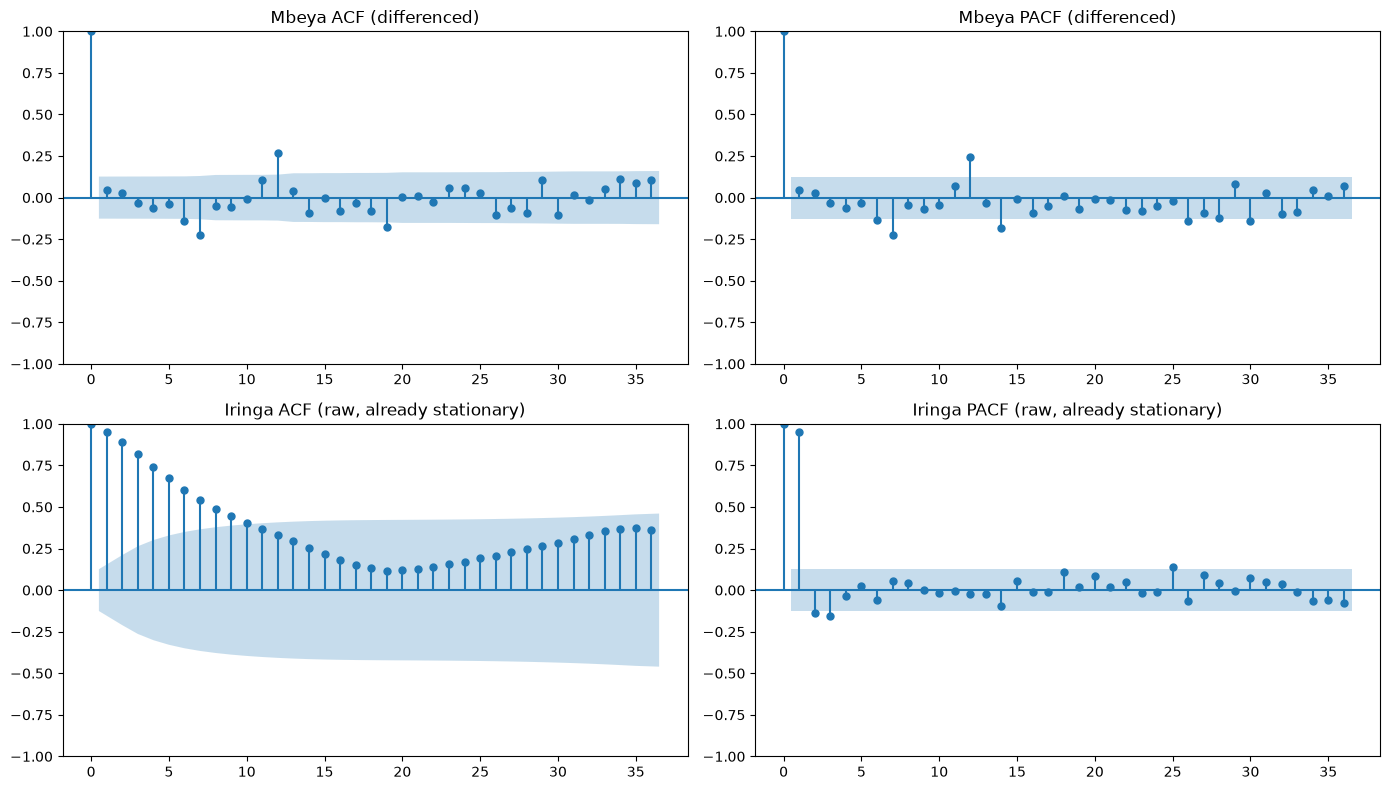

In [13]:
# ACF and PACF -- on the DIFFERENCED series for Mbeya (since raw is non-stationary)
# and on the RAW series for Iringa (since raw is already stationary)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

mbeya_stationary = mbeya_series.diff().dropna()
iringa_stationary = iringa_series  # already stationary, no differencing needed

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(mbeya_stationary, lags=36, ax=axes[0, 0])
axes[0, 0].set_title("Mbeya ACF (differenced)")
plot_pacf(mbeya_stationary, lags=36, ax=axes[0, 1])
axes[0, 1].set_title("Mbeya PACF (differenced)")

plot_acf(iringa_stationary, lags=36, ax=axes[1, 0])
axes[1, 0].set_title("Iringa ACF (raw, already stationary)")
plot_pacf(iringa_stationary, lags=36, ax=axes[1, 1])
axes[1, 1].set_title("Iringa PACF (raw, already stationary)")

plt.tight_layout()
plt.savefig("../reports/figures/acf_pacf_both_regions.png", dpi=150)
plt.show()

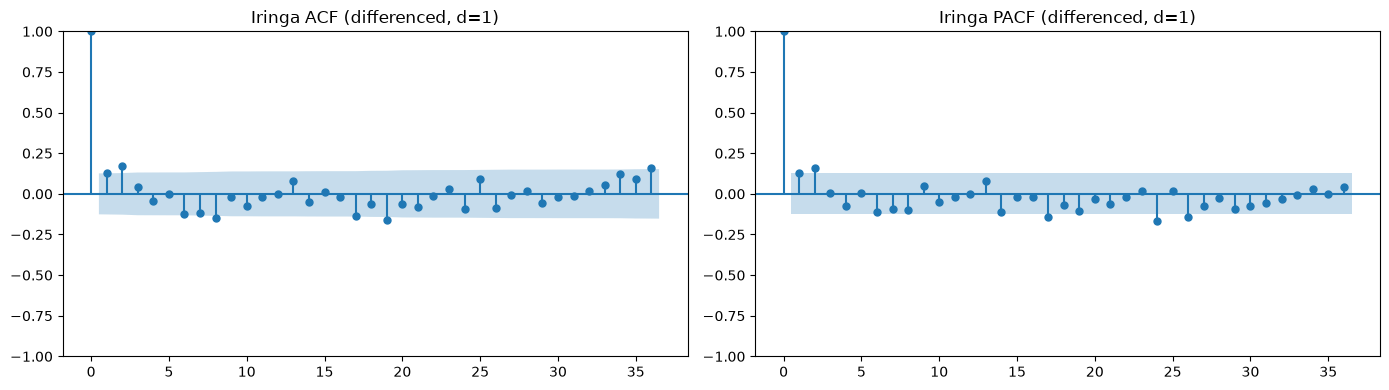

In [14]:
iringa_diff = iringa_series.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(iringa_diff, lags=36, ax=axes[0])
axes[0].set_title("Iringa ACF (differenced, d=1)")
plot_pacf(iringa_diff, lags=36, ax=axes[1])
axes[1].set_title("Iringa PACF (differenced, d=1)")
plt.tight_layout()
plt.savefig("../reports/figures/iringa_acf_pacf_differenced.png", dpi=150)
plt.show()